# Pottery vs non-pottery classification

Binary classifier trained the same way as [type_model.ipynb](type_model.ipynb): **DINOv2-large** features, flip augmentations (metadata + on-the-fly), **sklearn** hyperparameter search.

- **Positive class (1):** pottery — all PNGs under `tests/data/pottery/type` (same folder layout as the type model: `base`, `body`, `rim`, `appendage/...`).
- **Negative class (0):** non-pottery — flat folder `tests/data/not_pottery` (`*.png` only).

Run from repo root or from `notebooks/`; paths resolve to `tests/data/...` under the repository root.


In [1]:
# Imports and seeds
import torch
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
import joblib
import time
import glob
import os
from pathlib import Path
import seaborn as sns

try:
    from transformers import AutoModel
    print("Hugging Face transformers available")
except ImportError:
    raise ImportError("pip install transformers")

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available (optional)")

torch.manual_seed(42)
np.random.seed(42)
print("PyTorch", torch.__version__, "CUDA:", torch.cuda.is_available())


Hugging Face transformers available
XGBoost available
PyTorch 2.8.0+cu126 CUDA: True


In [2]:
# Repository root and data paths
def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in (cwd, cwd.parent):
        if (p / "tests" / "data").is_dir():
            return p
    return cwd

REPO_ROOT = find_repo_root()
POTTERY_TYPE_DIR = REPO_ROOT / "tests" / "data" / "pottery" / "type"
NOT_POTTERY_DIR = REPO_ROOT / "tests" / "data" / "not_pottery"
MODELS_DIR = REPO_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT =", REPO_ROOT)
print("POTTERY_TYPE_DIR exists:", POTTERY_TYPE_DIR.is_dir(), "->", POTTERY_TYPE_DIR)
print("NOT_POTTERY_DIR exists:", NOT_POTTERY_DIR.is_dir(), "->", NOT_POTTERY_DIR)


def convert_rgba_to_rgb(image):
    if image.mode == "RGBA":
        background = Image.new("RGB", image.size, (255, 255, 255))
        background.paste(image, mask=image.split()[-1])
        return background
    if image.mode != "RGB":
        return image.convert("RGB")
    return image


def load_pottery_type_tree(data_dir: Path):
    # Same layout as type_model load_type_images; every image is pottery (binary).
    images = []
    part_labels = []
    filenames = []

    main_classes = ["base", "body", "rim"]
    appendage_classes = ["lid", "rim-handle", "spout", "rounded", "body-decorated", "tile"]

    data_dir = Path(data_dir)
    if not data_dir.is_dir():
        raise FileNotFoundError(f"Pottery type directory not found: {data_dir}")

    for class_name in main_classes:
        class_dir = data_dir / class_name
        if not class_dir.is_dir():
            print(f"Warning: missing {class_dir}, skipping")
            continue
        files = sorted(glob.glob(str(class_dir / "*.png")))
        print(f"Found {len(files)} {class_name} images")
        for file_path in files:
            try:
                img = Image.open(file_path)
                img = convert_rgba_to_rgb(img)
                images.append(img)
                part_labels.append(class_name)
                filenames.append(f"pottery/{class_name}/{os.path.basename(file_path)}")
            except Exception as e:
                print(f"Error loading {file_path}: {e}")

    for class_name in appendage_classes:
        class_dir = data_dir / "appendage" / class_name
        if not class_dir.is_dir():
            print(f"Warning: missing {class_dir}, skipping")
            continue
        files = sorted(glob.glob(str(class_dir / "*.png")))
        print(f"Found {len(files)} appendage/{class_name} images")
        for file_path in files:
            try:
                img = Image.open(file_path)
                img = convert_rgba_to_rgb(img)
                images.append(img)
                part_labels.append(f"appendage/{class_name}")
                filenames.append(f"pottery/appendage/{class_name}/{os.path.basename(file_path)}")
            except Exception as e:
                print(f"Error loading {file_path}: {e}")

    return images, part_labels, filenames


def load_non_pottery_flat(data_dir: Path):
    # Flat folder of PNGs only.
    data_dir = Path(data_dir)
    if not data_dir.is_dir():
        raise FileNotFoundError(f"Non-pottery directory not found: {data_dir}")

    files = sorted(glob.glob(str(data_dir / "*.png")))
    print(f"Found {len(files)} non-pottery images in {data_dir}")
    images = []
    filenames = []
    for file_path in files:
        try:
            img = Image.open(file_path)
            img = convert_rgba_to_rgb(img)
            images.append(img)
            filenames.append(f"not_pottery/{os.path.basename(file_path)}")
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    return images, filenames


pot_imgs, pot_parts, pot_names = load_pottery_type_tree(POTTERY_TYPE_DIR)
non_imgs, non_names = load_non_pottery_flat(NOT_POTTERY_DIR)

if len(pot_imgs) == 0:
    raise RuntimeError("No pottery images loaded. Check tests/data/pottery/type layout and PNG files.")
if len(non_imgs) == 0:
    raise RuntimeError("No non-pottery images loaded. Add PNGs to tests/data/not_pottery.")

images = pot_imgs + non_imgs
binary_labels = np.array([1] * len(pot_imgs) + [0] * len(non_imgs), dtype=np.int64)
part_labels = pot_parts + ["non_pottery"] * len(non_imgs)
filenames = pot_names + non_names

print(f"\nMerged: {len(images)} images | pottery={int(binary_labels.sum())} | non_pottery={int((binary_labels==0).sum())}")

from collections import Counter

print("Pottery part counts:", Counter(pot_parts))


REPO_ROOT = G:\GitHub\ascota
POTTERY_TYPE_DIR exists: True -> G:\GitHub\ascota\tests\data\pottery\type
NOT_POTTERY_DIR exists: True -> G:\GitHub\ascota\tests\data\not_pottery
Found 334 base images
Error loading G:\GitHub\ascota\tests\data\pottery\type\base\165-1-3000.png: image file is truncated
Found 1828 body images
Found 1861 rim images
Found 4 appendage/lid images
Found 9 appendage/rim-handle images
Found 9 appendage/spout images
Found 30 appendage/rounded images
Found 20 appendage/body-decorated images
Found 3 appendage/tile images
Found 4533 non-pottery images in G:\GitHub\ascota\tests\data\not_pottery

Merged: 8630 images | pottery=4097 | non_pottery=4533
Pottery part counts: Counter({'rim': 1861, 'body': 1828, 'base': 333, 'appendage/rounded': 30, 'appendage/body-decorated': 20, 'appendage/rim-handle': 9, 'appendage/spout': 9, 'appendage/lid': 4, 'appendage/tile': 3})


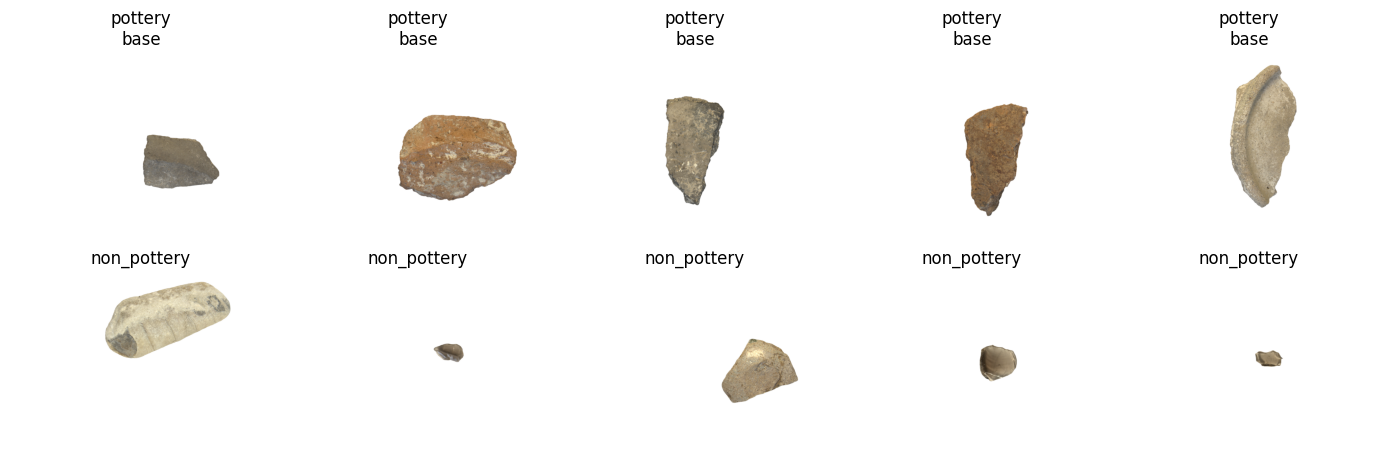

In [3]:
# Sample grid
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for i in range(5):
    idx = i
    axes[0, i].imshow(images[idx])
    axes[0, i].set_title(f"pottery\n{part_labels[idx][:20]}")
    axes[0, i].axis("off")
for i in range(5):
    idx = len(pot_imgs) + i
    if idx < len(images):
        axes[1, i].imshow(images[idx])
        axes[1, i].set_title("non_pottery")
        axes[1, i].axis("off")
plt.tight_layout()
plt.show()


In [4]:
# Augmentation metadata (memory-efficient)
def apply_augmentation(image, aug_type):
    if aug_type in ("original", "none"):
        return image.copy()
    if aug_type in ("horizontal", "h_flip"):
        return image.transpose(Image.FLIP_LEFT_RIGHT)
    if aug_type in ("vertical", "v_flip"):
        return image.transpose(Image.FLIP_TOP_BOTTOM)
    if aug_type in ("both", "hv_flip"):
        img_h = image.transpose(Image.FLIP_LEFT_RIGHT)
        return img_h.transpose(Image.FLIP_TOP_BOTTOM)
    return image.copy()


def create_augmentation_metadata_binary(
    images,
    binary_labels,
    part_labels,
    filenames,
    pottery_aug_factor=2,
    non_pottery_aug_factor=2,
):
    plan = []
    print("Creating augmentation plan...")
    print(f"  pottery_aug_factor={pottery_aug_factor}, non_pottery_aug_factor={non_pottery_aug_factor}")

    for i, (y, part, fn) in enumerate(zip(binary_labels, part_labels, filenames)):
        if y == 1:
            aug_factor = pottery_aug_factor
            cls_name = "pottery"
        else:
            aug_factor = non_pottery_aug_factor
            cls_name = "non_pottery"
        available = (
            ["original", "h_flip", "v_flip", "hv_flip"] if aug_factor >= 4 else ["original", "h_flip", "v_flip"]
        )
        if aug_factor == 1:
            selected = ["original"]
        else:
            n = min(len(available), aug_factor)
            selected = available[:n]
        for aug_type in selected:
            plan.append(
                {
                    "original_idx": i,
                    "aug_type": aug_type,
                    "class_name": cls_name,
                    "part_label": part,
                    "filename": f"{fn}_aug_{aug_type}",
                }
            )

    print(f"  Original images: {len(images)}  ->  augmented rows: {len(plan)}")
    return plan


# Bump minority side if imbalanced
n_pot, n_non = int(binary_labels.sum()), int((binary_labels == 0).sum())
pottery_aug_factor, non_pottery_aug_factor = 2, 2
if n_pot < n_non:
    pottery_aug_factor = min(5, max(2, int(round(n_non / max(n_pot, 1)))))
elif n_non < n_pot:
    non_pottery_aug_factor = min(5, max(2, int(round(n_pot / max(n_non, 1)))))
print(f"Aug factors (auto-balance hint): pottery={pottery_aug_factor}, non_pottery={non_pottery_aug_factor}")

augmentation_plan = create_augmentation_metadata_binary(
    images,
    binary_labels,
    part_labels,
    filenames,
    pottery_aug_factor=pottery_aug_factor,
    non_pottery_aug_factor=non_pottery_aug_factor,
)

y_augmented = np.array([1 if e["class_name"] == "pottery" else 0 for e in augmentation_plan], dtype=np.int64)
print(f"y_augmented: pottery={int(y_augmented.sum())}, non_pottery={int((y_augmented==0).sum())}")


Aug factors (auto-balance hint): pottery=2, non_pottery=2
Creating augmentation plan...
  pottery_aug_factor=2, non_pottery_aug_factor=2
  Original images: 8630  ->  augmented rows: 17260
y_augmented: pottery=8194, non_pottery=9066


In [5]:
# DINOv2-large
def load_dinov2_model():
    print("Loading facebook/dinov2-large ...")
    model = AutoModel.from_pretrained("facebook/dinov2-large")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)
    print("Device:", device)
    return model, device


dino_model, device = load_dinov2_model()


Loading facebook/dinov2-large ...
Device: cuda


In [6]:
# Feature extraction + cache
FEATURES_PATH = MODELS_DIR / "pottery_binary_features_dinov2_large.npy"
LABELS_PATH = MODELS_DIR / "pottery_binary_labels_dinov2_large.npy"
USE_FEATURE_CACHE = False  # set True to skip re-extraction if files exist


def extract_features_with_augmentation(model, images, augmentation_plan, device, batch_size=32):
    transform = transforms.Compose(
        [
            transforms.Resize(224),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )
    feats = []
    model.eval()
    n = len(augmentation_plan)
    print(f"Extracting features for {n} augmented samples...")
    for batch_start in range(0, n, batch_size):
        batch_end = min(batch_start + batch_size, n)
        batch_plan = augmentation_plan[batch_start:batch_end]
        tensors = []
        for item in batch_plan:
            orig = images[item["original_idx"]]
            aug_img = apply_augmentation(orig, item["aug_type"])
            tensors.append(transform(aug_img))
        batch_tensor = torch.stack(tensors).to(device)
        with torch.no_grad():
            out = model(batch_tensor)
            if hasattr(out, "pooler_output") and out.pooler_output is not None:
                bf = out.pooler_output
            else:
                bf = out.last_hidden_state.mean(dim=1)
        feats.append(bf.cpu().numpy())
        if batch_end % 500 == 0 or batch_end >= n:
            print(f"  {batch_end}/{n}")
        if (batch_start // batch_size) % 50 == 0 and torch.cuda.is_available():
            torch.cuda.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    X = np.vstack(feats)
    print("Feature shape:", X.shape)
    return X


if USE_FEATURE_CACHE and FEATURES_PATH.is_file() and LABELS_PATH.is_file():
    features = np.load(FEATURES_PATH)
    y_augmented = np.load(LABELS_PATH)
    print("Loaded cached features", features.shape)
else:
    features = extract_features_with_augmentation(dino_model, images, augmentation_plan, device, batch_size=32)
    np.save(FEATURES_PATH, features)
    np.save(LABELS_PATH, y_augmented)
    print("Saved", FEATURES_PATH, "and", LABELS_PATH)


Extracting features for 17260 augmented samples...
  4000/17260
  8000/17260
  12000/17260
  16000/17260
  17260/17260
Feature shape: (17260, 1024)
Saved G:\GitHub\ascota\models\pottery_binary_features_dinov2_large.npy and G:\GitHub\ascota\models\pottery_binary_labels_dinov2_large.npy


In [7]:
# Train / test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    features, y_augmented, test_size=0.2, random_state=42, stratify=y_augmented
)
print("Train", X_train.shape[0], "| Test", X_test.shape[0])
print("Train pottery=", int(y_train.sum()), "non=", int((y_train == 0).sum()))


Train 13808 | Test 3452
Train pottery= 6555 non= 7253


In [8]:
# Hyperparameter search (same pattern as type_model Stage 1)


def get_binary_param_grids():
    grids = {}
    grids["logistic_regression"] = {
        "C": np.logspace(-2, 2, 9),
        "penalty": ["l2", "elasticnet"],
        "solver": ["lbfgs", "saga"],
        "max_iter": [1000],
        "class_weight": ["balanced", None],
    }
    grids["svm_linear"] = {
        "C": np.logspace(-2, 2, 9),
        "class_weight": ["balanced", None],
    }
    grids["svm_rbf"] = {
        "C": np.logspace(-1, 3, 9),
        "gamma": ["scale", "auto"] + list(np.logspace(-3, 0, 4)),
        "class_weight": ["balanced", None],
    }
    grids["random_forest"] = {
        "n_estimators": [200],
        "max_depth": [20],
        "min_samples_split": [2],
        "min_samples_leaf": [1],
        "max_features": ["sqrt"],
        "class_weight": ["balanced"],
    }
    if XGBOOST_AVAILABLE:
        grids["xgboost"] = {
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth": [5, 7, 10],
            "n_estimators": [200, 300],
            "subsample": [0.8, 0.9],
            "colsample_bytree": [0.8, 0.9],
            "scale_pos_weight": [1, 2],
        }
    return grids


def train_binary_models(X_train, y_train, X_test, y_test, cv_folds=3):
    print("Pottery vs non-pottery — model search")
    grids = get_binary_param_grids()
    results = {}
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    n_iter = 25

    def fit_report(name, base_est, param_grid):
        gs = RandomizedSearchCV(
            base_est,
            param_grid,
            cv=skf,
            scoring="balanced_accuracy",
            n_iter=n_iter,
            random_state=42,
            verbose=1,
        )
        t0 = time.time()
        gs.fit(X_train, y_train)
        dt = time.time() - t0
        clf = gs.best_estimator_
        pred = clf.predict(X_test)
        proba = clf.predict_proba(X_test)
        results[name] = {
            "classifier": clf,
            "best_params": gs.best_params_,
            "best_cv_score": gs.best_score_,
            "test_accuracy": accuracy_score(y_test, pred),
            "test_f1": f1_score(y_test, pred),
            "test_precision": precision_score(y_test, pred),
            "test_recall": recall_score(y_test, pred),
            "train_time": dt,
            "predict_proba": proba,
        }
        print(
            "  CV=",
            round(gs.best_score_, 4),
            " acc=",
            round(results[name]["test_accuracy"], 4),
            " f1=",
            round(results[name]["test_f1"], 4),
            " time_s=",
            round(dt, 1),
        )

    print("LogisticRegression...")
    fit_report("logistic_regression", LogisticRegression(random_state=42), grids["logistic_regression"])

    print("Linear SVM...")
    fit_report("svm_linear", SVC(kernel="linear", random_state=42, probability=True), grids["svm_linear"])

    print("RBF SVM...")
    fit_report("svm_rbf", SVC(kernel="rbf", random_state=42, probability=True), grids["svm_rbf"])

    print("Skipping Random Forest (slow); set SKIP_RANDOM_FOREST=False to enable")
    SKIP_RANDOM_FOREST = True
    if not SKIP_RANDOM_FOREST:
        fit_report("random_forest", RandomForestClassifier(random_state=42), grids["random_forest"])

    if XGBOOST_AVAILABLE:
        print("XGBoost...")
        fit_report("xgboost", xgb.XGBClassifier(random_state=42, eval_metric="logloss"), grids["xgboost"])

    best_name = max(results, key=lambda k: results[k]["best_cv_score"])
    print("Best by CV:", best_name, results[best_name]["best_cv_score"])
    return results, best_name


binary_results, best_binary_model = train_binary_models(X_train, y_train, X_test, y_test)

best_clf = binary_results[best_binary_model]["classifier"]
best_params = binary_results[best_binary_model]["best_params"]
joblib.dump(best_clf, MODELS_DIR / f"pottery_binary_{best_binary_model}_optimized.pkl")
joblib.dump(best_params, MODELS_DIR / f"pottery_binary_{best_binary_model}_params.pkl")
print("Saved", MODELS_DIR / f"pottery_binary_{best_binary_model}_optimized.pkl")


Pottery vs non-pottery — model search
LogisticRegression...
Fitting 3 folds for each of 25 candidates, totalling 75 fits


g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached 

  CV= 0.9882  acc= 0.9919  f1= 0.9915  time_s= 627.6
Linear SVM...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
  CV= 0.9879  acc= 0.9887  f1= 0.9881  time_s= 247.1
RBF SVM...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
  CV= 0.9935  acc= 0.9968  f1= 0.9966  time_s= 6117.5
Skipping Random Forest (slow); set SKIP_RANDOM_FOREST=False to enable
XGBoost...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
  CV= 0.9854  acc= 0.9902  f1= 0.9896  time_s= 548.1
Best by CV: svm_rbf 0.9934508117633148
Saved G:\GitHub\ascota\models\pottery_binary_svm_rbf_optimized.pkl


              precision    recall  f1-score   support

 non_pottery       1.00      1.00      1.00      1813
     pottery       1.00      1.00      1.00      1639

    accuracy                           1.00      3452
   macro avg       1.00      1.00      1.00      3452
weighted avg       1.00      1.00      1.00      3452

Confusion [ [TN FP] [FN TP] ]:
[[1808    5]
 [   6 1633]]
ROC-AUC (pottery positive): 0.9997


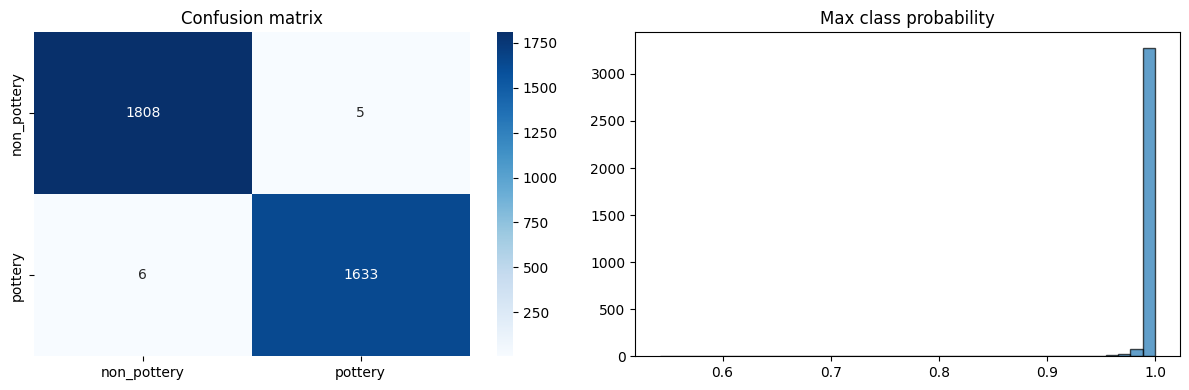

In [9]:
# Evaluation + ROC-AUC
def evaluate_binary(results, model_name, X_test, y_test):
    clf = results[model_name]["classifier"]
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    print(classification_report(y_test, y_pred, target_names=["non_pottery", "pottery"]))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion [ [TN FP] [FN TP] ]:")
    print(cm)
    try:
        auc = roc_auc_score(y_test, y_proba)
        print("ROC-AUC (pottery positive):", round(auc, 4))
    except ValueError as e:
        print("ROC-AUC skipped:", e)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0],
        xticklabels=["non_pottery", "pottery"],
        yticklabels=["non_pottery", "pottery"],
    )
    axes[0].set_title("Confusion matrix")
    conf = np.maximum(y_proba, 1 - y_proba)
    axes[1].hist(conf, bins=40, edgecolor="black", alpha=0.7)
    axes[1].set_title("Max class probability")
    plt.tight_layout()
    plt.show()
    return y_pred, y_proba


y_pred, y_proba = evaluate_binary(binary_results, best_binary_model, X_test, y_test)


In [10]:
# One-image inference (same preprocessing as training)
def pottery_proba_from_path(image_path: Path, model, clf, device):
    img = Image.open(image_path)
    img = convert_rgba_to_rgb(img)
    transform = transforms.Compose(
        [
            transforms.Resize(224),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )
    t = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        out = model(t)
        if hasattr(out, "pooler_output") and out.pooler_output is not None:
            vec = out.pooler_output
        else:
            vec = out.last_hidden_state.mean(dim=1)
    x = vec.cpu().numpy()
    p_pottery = float(clf.predict_proba(x)[0, 1])
    label = "pottery" if p_pottery >= 0.5 else "non_pottery"
    return label, p_pottery


# Example: first pottery (body/) and first non image if present
ex_pot = POTTERY_TYPE_DIR / "body"
pot_files = sorted(glob.glob(str(ex_pot / "*.png"))) if ex_pot.is_dir() else []
ex_non = sorted(glob.glob(str(NOT_POTTERY_DIR / "*.png")))
if pot_files:
    lp, pp = pottery_proba_from_path(Path(pot_files[0]), dino_model, best_clf, device)
    print("Example pottery:", pot_files[0], "->", lp, "p(pottery)=", round(pp, 3))
if ex_non:
    ln, pn = pottery_proba_from_path(Path(ex_non[0]), dino_model, best_clf, device)
    print("Example non:", ex_non[0], "->", ln, "p(pottery)=", round(pn, 3))


Example pottery: G:\GitHub\ascota\tests\data\pottery\type\body\10-1-3000.png -> pottery p(pottery)= 1.0
Example non: G:\GitHub\ascota\tests\data\not_pottery\10-1-3000.png -> non_pottery p(pottery)= 0.004
